# Kalman Filter

A linear Kalman filter that tracks a moving point in 2D from noisy position
measurements. We estimate a 4-D state — position **and** velocity — even though
we only observe position. The velocity components fall out of the recursion
because the filter knows positions at successive times must be linked by a
constant-velocity motion model.

The dataset is a synthetic trajectory (`groundTruth.csv`) sampled at 20 Hz
with Gaussian noise added (`measurmens.csv`). We compare our from-scratch
output to OpenCV's `cv2.KalmanFilter` (`kalmanv.csv`).

Notation follows the excellent visual explainer at
[bzarg.com/p/how-a-kalman-filter-works-in-pictures](https://www.bzarg.com/p/how-a-kalman-filter-works-in-pictures/).


## State and measurement model

State vector (position + velocity in 2D):

$$
\mathbf{x}_t = \begin{bmatrix} p_x \\ p_y \\ v_x \\ v_y \end{bmatrix}
$$

Measurement (position only):

$$
\mathbf{z}_t = \begin{bmatrix} z_x \\ z_y \end{bmatrix}
$$

With sample period $\Delta t$, the constant-velocity transition and
position-only observation matrices are

$$
F = \begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}, \qquad
H = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}.
$$


## The Kalman recursion

**Predict** — propagate the state and covariance through the motion model:

$$
\hat{\mathbf{x}}_{t \mid t-1} = F\, \hat{\mathbf{x}}_{t-1 \mid t-1} + B\, \mathbf{u}_t
$$

$$
P_{t \mid t-1} = F\, P_{t-1 \mid t-1}\, F^{\top} + Q
$$

**Update** — fold in the new measurement $\mathbf{z}_t$:

$$
\mathbf{y}_t = \mathbf{z}_t - H\, \hat{\mathbf{x}}_{t \mid t-1} \quad \text{(innovation)}
$$

$$
S_t = H\, P_{t \mid t-1}\, H^{\top} + R \quad \text{(innovation covariance)}
$$

$$
K_t = P_{t \mid t-1}\, H^{\top}\, S_t^{-1} \quad \text{(Kalman gain)}
$$

$$
\hat{\mathbf{x}}_{t \mid t} = \hat{\mathbf{x}}_{t \mid t-1} + K_t\, \mathbf{y}_t
$$

$$
P_{t \mid t} = (I - K_t\, H)\, P_{t \mid t-1}
$$

The gain $K_t$ is a tradeoff knob: when the measurement is precise ($R$
small) it leans on $\mathbf{z}_t$; when the prediction is precise ($P$
small) it leans on $\hat{\mathbf{x}}_{t \mid t-1}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.set_printoptions(suppress=True, precision=4)

DATA = Path("data")
ground_truth = np.genfromtxt(DATA / "groundTruth.csv", delimiter=",", skip_header=1)
measurements = np.genfromtxt(DATA / "measurmens.csv", delimiter=",", skip_header=1)
opencv_ref   = np.genfromtxt(DATA / "kalmanv.csv",     delimiter=",", skip_header=1)

print(f"ground truth: {ground_truth.shape}")
print(f"measurements: {measurements.shape}")
print(f"opencv ref:   {opencv_ref.shape}")


ground truth: (117, 2)
measurements: (116, 2)
opencv ref:   (116, 2)


## Filter matrices

In [2]:
dt = 1 / 20.0  # 20 Hz sample period

# Constant-velocity transition
F = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1,  0],
              [0, 0, 0,  1]])

# Observe position only
H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

# No control input here (zero acceleration)
B = np.zeros((4, 1))
u = np.array([[0.0]])

# Process noise — how much we trust the constant-velocity assumption
Q = np.eye(4)

# Measurement noise — variance of the position sensor (px^2)
R = np.eye(2) * 5.0

# Initial covariance — small, we'll let the filter inflate it if needed
P = np.eye(4) * 0.2

# Initial state — at the origin, at rest
x = np.zeros((4, 1))


## Predict / update

In [3]:
def predict(x, P, F, B, u, Q):
    x = F @ x + B @ u
    P = F @ P @ F.T + Q
    return x, P


def update(x, P, z, H, R):
    y = z - H @ x                       # innovation
    S = H @ P @ H.T + R                 # innovation covariance
    K = P @ H.T @ np.linalg.inv(S)      # Kalman gain
    x = x + K @ y
    P = (np.eye(P.shape[0]) - K @ H) @ P
    return x, P, K


## Run the filter

In [4]:
estimates = np.zeros_like(measurements)

for i, z in enumerate(measurements):
    x, P    = predict(x, P, F, B, u, Q)
    z       = z.reshape(2, 1)
    x, P, K = update(x, P, z, H, R)
    estimates[i] = x[:2, 0]

print(f"final state:\n{x.ravel()}")
print(f"final gain (truncated):\n{K}")


final state:
[ 102.8736  322.0949 -114.0931   30.559 ]
final gain (truncated):
[[0.3881 0.    ]
 [0.     0.3881]
 [0.3498 0.    ]
 [0.     0.3498]]


## Compare against ground truth and OpenCV

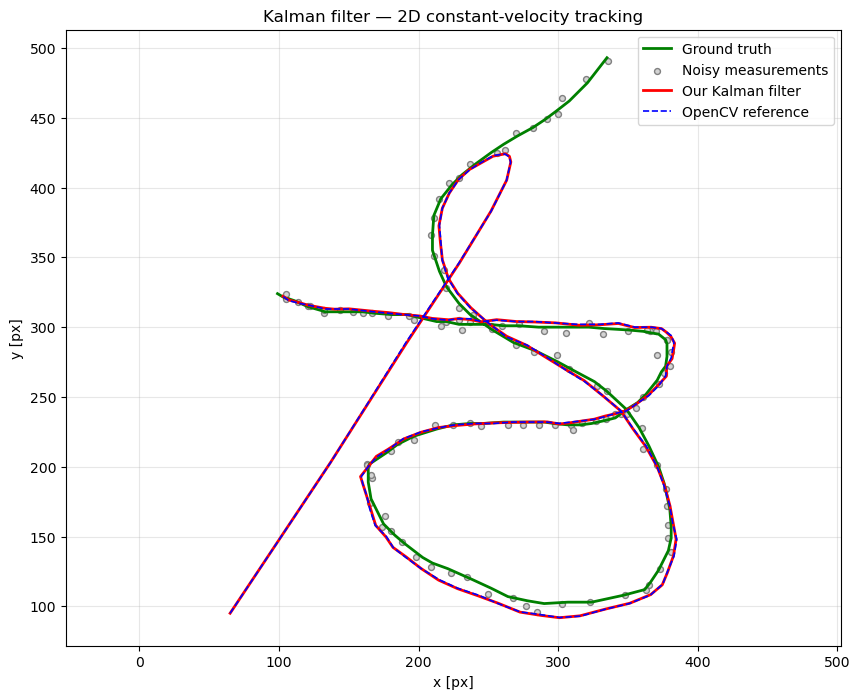

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(ground_truth[:, 0], ground_truth[:, 1], "g-",  lw=2,  label="Ground truth")
ax.scatter(measurements[:, 0], measurements[:, 1], s=18, c="lightgray",
           edgecolors="gray", label="Noisy measurements")
ax.plot(estimates[:, 0], estimates[:, 1], "r-",  lw=2,  label="Our Kalman filter")
ax.plot(opencv_ref[:, 0], opencv_ref[:, 1], "b--", lw=1.2, label="OpenCV reference")

ax.set_xlabel("x [px]")
ax.set_ylabel("y [px]")
ax.set_title("Kalman filter — 2D constant-velocity tracking")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


## What to look at

* The **red** (our filter) and **blue dashed** (OpenCV) curves should sit
  almost on top of each other — small offsets are expected because OpenCV
  uses slightly different default tuning, but the shape should match.
* Both estimates lag the **green** truth slightly at the start while the
  filter learns the velocity, then track it closely.
* Try raising `R` (more measurement noise) — the filter will smooth more
  aggressively. Drop `Q` and it will trust the motion model more, which
  fails as soon as the trajectory curves.
